# Optimizing Time Series Forecasting: LSTM and GRU with EDAIN on HPC Workload Traces
Forecasting the number of jobs submitted per time slice, with EDAIN adaptive input normalization in front of the recurrent networks.

## 1. Setup
Imports, global constants, and random seeds.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate
from tensorflow.keras.layers import Dense, Dropout, GRU, LSTM
from tensorflow.keras.optimizers import Adam

sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
DATASET_PATH = "/kaggle/input/datasets/avtnenet/parallel-workloads-archive/25-LLNL-uBGL-2006-2.parquet"

SLICE_MINUTES = 15
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.85

FEATURE_COLS = [
    'num_jobs', 'total_allocated_proc', 'std_allocated_proc', 'total_run_time',
    'std_run_time', 'avg_allocated_proc', 'avg_run_time',
]
TARGET_COL = 'num_jobs'

MODEL_TYPES = ['LSTM', 'GRU']
WINDOW_CANDIDATES = [30, 60, 90, 120]
BATCH_SIZE = 32
EPOCHS = 50
BASE_LR = 1e-3

EDAIN_LR_SCALES = {'outlier': 100.0, 'shift': 0.01, 'scale': 0.01, 'power': 10.0}

SEED = 42

In [3]:
tf.keras.utils.set_random_seed(SEED)

## 2. Data Preparation
Load the Parquet trace, convert `submit_time` to seconds since the first job, and aggregate jobs into fixed time slices.

In [4]:
def preprocess_data(path, slice_minutes):
    jobs = pd.read_parquet(path, columns=['submit_time', 'run_time', 'allocated_proc'])
    jobs = jobs.astype({'run_time': 'float64', 'allocated_proc': 'float64'})

    unix_time = (jobs['submit_time'] - pd.Timestamp('1970-01-01', tz='UTC')).dt.total_seconds()
    jobs['submit_time'] = unix_time - unix_time.min()

    jobs = jobs[jobs['run_time'] > 0].copy()
    jobs['slice'] = (jobs['submit_time'] // (slice_minutes * 60)).astype('int64')

    data_agg = jobs.groupby('slice').agg(
        num_jobs=('run_time', 'size'),
        total_run_time=('run_time', 'sum'),
        std_run_time=('run_time', 'std'),
        total_allocated_proc=('allocated_proc', 'sum'),
        std_allocated_proc=('allocated_proc', 'std'),
    )
    data_agg['avg_allocated_proc'] = data_agg['total_allocated_proc'] / data_agg['num_jobs']
    data_agg['avg_run_time'] = data_agg['total_run_time'] / data_agg['num_jobs']

    full_range = np.arange(data_agg.index.min(), data_agg.index.max() + 1)
    data_agg = data_agg.reindex(full_range, fill_value=0).fillna(0)

    return data_agg.reset_index(drop=True)[FEATURE_COLS]


df = preprocess_data(DATASET_PATH, SLICE_MINUTES)
df

,num_jobs,total_allocated_proc,std_allocated_proc,total_run_time,std_run_time,avg_allocated_proc,avg_run_time
0,2,512.0,0.0,14393.0,6.363961,256.0,7196.5
1,0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0,0.0,0.0,0.0,0.000000,0.0,0.0
3,1,1024.0,0.0,3355.0,0.000000,1024.0,3355.0
4,0,0.0,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...
21345,0,0.0,0.0,0.0,0.000000,0.0,0.0
21346,1,1024.0,0.0,2892.0,0.000000,1024.0,2892.0
21347,0,0.0,0.0,0.0,0.000000,0.0,0.0
21348,0,0.0,0.0,0.0,0.000000,0.0,0.0


## 3. Splitting and Scaling
Chronological 70/15/15 split; a z-score scaler fitted on the training rows only precedes EDAIN, as the repository recommends for the global-aware layer.

In [5]:
dataset = df[FEATURE_COLS].to_numpy(dtype=np.float64)
n_features = len(FEATURE_COLS)
target_idx = FEATURE_COLS.index(TARGET_COL)

train_end = int(np.ceil(len(dataset) * TRAIN_FRACTION))
val_end = int(np.ceil(len(dataset) * VALIDATION_FRACTION))

print(f"Training: {train_end} | Validation: {val_end - train_end} | Test: {len(dataset) - val_end}")
print("Features:", FEATURE_COLS)
print("Target:", TARGET_COL, "| index:", target_idx)

Training: 14945 | Validation: 3203 | Test: 3202
Features: ['num_jobs', 'total_allocated_proc', 'std_allocated_proc', 'total_run_time', 'std_run_time', 'avg_allocated_proc', 'avg_run_time']
Target: num_jobs | index: 0


In [6]:
scaler = StandardScaler().fit(dataset[:train_end])
scaled_data = scaler.transform(dataset).astype(np.float32)

target_mean = float(scaler.mean_[target_idx])
target_std = float(scaler.scale_[target_idx])

In [7]:
def create_sequences(start_idx, end_idx, window_size):
    x = np.stack([scaled_data[i - window_size:i] for i in range(start_idx + window_size, end_idx)])
    y_scaled = scaled_data[start_idx + window_size:end_idx, target_idx:target_idx + 1]
    y_raw = dataset[start_idx + window_size:end_idx, target_idx:target_idx + 1]
    return x.astype(np.float32), y_scaled, y_raw

## 4. Error Metrics
Iverson-bracket metrics that only score time slices where the actual value is non-zero.

In [8]:
def flatten(array):
    return np.asarray(array, dtype=float).reshape(-1)


def iverson_mse(actual, prediction):
    actual, prediction = flatten(actual), flatten(prediction)
    iverson = actual != 0.0

    return ((prediction - actual) ** 2 * iverson).sum() / iverson.sum()


def iverson_mae(actual, prediction):
    actual, prediction = flatten(actual), flatten(prediction)
    iverson = actual != 0.0

    return (np.abs(prediction - actual) * iverson).sum() / iverson.sum()


def iverson_rmse(actual, prediction):
    return np.sqrt(iverson_mse(actual, prediction))

## 5. EDAIN Layer
Keras translation of the global-aware EDAIN layer from [marcusGH/edain_paper](https://github.com/marcusGH/edain_paper), applying outlier removal, shift, scale, and a Yeo-Johnson power transform with learnable parameters.

In [9]:
class AdaptiveOutlierRemoval(tf.keras.layers.Layer):
    def __init__(self, residual_connection=True, mode='exp', min_beta=1.0, init_sigma=0.1, **kwargs):
        super().__init__(**kwargs)
        if mode not in ('exp', 'softplus'):
            raise ValueError(f"Unknown outlier removal mode: {mode}")
        self.residual_connection = residual_connection
        self.mode = mode
        self.min_beta = min_beta
        self.init_sigma = init_sigma

    def build(self, input_shape):
        window_size, dim = input_shape[1], input_shape[-1]
        self.log_cutoff = self.add_weight(
            name='log_cutoff', shape=(dim,),
            initializer=tf.keras.initializers.RandomNormal(1.0, self.init_sigma))
        if self.residual_connection:
            self.alpha = self.add_weight(
                name='alpha', shape=(dim,),
                initializer=tf.keras.initializers.RandomNormal(0.0, self.init_sigma))
        self.running_mean = self.add_weight(
            name='running_mean', shape=(window_size, dim), initializer='zeros', trainable=False)
        self.running_n = self.add_weight(
            name='running_n', shape=(), initializer='zeros', trainable=False)

    def call(self, x, training=False):
        mean = tf.convert_to_tensor(self.running_mean)
        if training:
            batch = tf.cast(tf.shape(x)[0], x.dtype)
            total = self.running_n + batch
            mean = (mean * self.running_n + tf.reduce_sum(tf.stop_gradient(x), axis=0)) / total
            self.running_mean.assign(mean)
            self.running_n.assign(total)

        if self.mode == 'exp':
            beta = self.min_beta + tf.exp(self.log_cutoff)
        else:
            beta = self.min_beta + tf.nn.softplus(self.log_cutoff)

        x_tanh = beta * tf.tanh((x - mean) / beta) + mean
        if self.residual_connection:
            gate = tf.sigmoid(self.alpha)
            return (1.0 - gate) * x + gate * x_tanh
        return x_tanh


class AdaptiveShift(tf.keras.layers.Layer):
    def __init__(self, init_sigma=0.1, **kwargs):
        super().__init__(**kwargs)
        self.init_sigma = init_sigma

    def build(self, input_shape):
        self.shift = self.add_weight(
            name='shift', shape=(input_shape[-1],),
            initializer=tf.keras.initializers.RandomNormal(0.0, self.init_sigma))

    def call(self, x, training=False):
        return x - self.shift


class AdaptiveScale(tf.keras.layers.Layer):
    def __init__(self, init_sigma=0.1, **kwargs):
        super().__init__(**kwargs)
        self.init_sigma = init_sigma

    def build(self, input_shape):
        self.log_scale = self.add_weight(
            name='log_scale', shape=(input_shape[-1],),
            initializer=tf.keras.initializers.RandomNormal(0.0, self.init_sigma))

    def call(self, x, training=False):
        return x * tf.exp(-self.log_scale)


class AdaptivePowerTransform(tf.keras.layers.Layer):
    def __init__(self, init_sigma=0.1, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.init_sigma = init_sigma
        self.eps = eps

    def build(self, input_shape):
        self.lambd = self.add_weight(
            name='lambd', shape=(input_shape[-1],),
            initializer=tf.keras.initializers.RandomNormal(1.0, self.init_sigma))

    def call(self, x, training=False):
        lam = tf.convert_to_tensor(self.lambd)
        abs_x = tf.abs(x)
        is_l0 = tf.abs(lam) < self.eps
        is_l2 = tf.abs(lam - 2.0) < self.eps
        safe_l0 = tf.where(is_l0, tf.ones_like(lam), lam)
        safe_l2 = tf.where(is_l2, tf.ones_like(lam), lam - 2.0)

        positive = tf.where(
            is_l0, tf.math.log1p(abs_x), (tf.pow(abs_x + 1.0, safe_l0) - 1.0) / safe_l0)
        negative = tf.where(
            is_l2, -tf.math.log1p(abs_x), (tf.pow(abs_x + 1.0, -safe_l2) - 1.0) / safe_l2)

        return tf.where(x >= 0.0, positive, negative)


class EDAINLayer(tf.keras.layers.Layer):
    def __init__(self, residual_connection=True, outlier_mode='exp', init_sigma=0.1, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.outlier_removal = AdaptiveOutlierRemoval(residual_connection, outlier_mode, init_sigma=init_sigma)
        self.shift = AdaptiveShift(init_sigma)
        self.scale = AdaptiveScale(init_sigma)
        self.power_transform = AdaptivePowerTransform(init_sigma, eps)

    def call(self, x, training=False):
        x = self.outlier_removal(x, training=training)
        x = self.shift(x, training=training)
        x = self.scale(x, training=training)
        return self.power_transform(x, training=training)

    def sublayers(self):
        return {
            'outlier': self.outlier_removal,
            'shift': self.shift,
            'scale': self.scale,
            'power': self.power_transform,
        }

## 6. Forecasting Model
EDAIN feeds an LSTM or GRU backbone, and each EDAIN sublayer is trained with its own learning-rate modifier as in the repository's example.

In [10]:
def clone_optimizer_with_lr(optimizer, learning_rate):
    config = optimizer.get_config()
    config['learning_rate'] = learning_rate
    return optimizer.__class__.from_config(config)


class EDAINForecastModel(tf.keras.Model):
    def __init__(self, edain_layer, backbone_layers, **kwargs):
        super().__init__(**kwargs)
        self.edain = edain_layer
        self.backbone_layers = backbone_layers
        self.loss_tracker = tf.keras.metrics.Mean(name='loss')

    def call(self, inputs, training=False):
        x = self.edain(inputs, training=training)
        for layer in self.backbone_layers:
            x = layer(x, training=training)
        return x

    def compile(self, optimizer, base_lr, lr_scales, **kwargs):
        super().compile(optimizer=optimizer, **kwargs)
        self.loss_fn = tf.keras.losses.MeanSquaredError()
        self.edain_optimizers = {
            name: clone_optimizer_with_lr(optimizer, base_lr * scale)
            for name, scale in lr_scales.items()
        }

    @property
    def metrics(self):
        return [self.loss_tracker]

    @staticmethod
    def apply_group(optimizer, grads, variables):
        pairs = [(g, v) for g, v in zip(grads, variables) if g is not None]
        if pairs:
            optimizer.apply_gradients(pairs)

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            pred = self(x, training=True)
            loss = self.loss_fn(y, pred)
            if self.losses:
                loss += tf.add_n(self.losses)

        variables = self.trainable_variables
        grads = dict(zip((id(v) for v in variables), tape.gradient(loss, variables)))

        edain_ids = set()
        for name, sublayer in self.edain.sublayers().items():
            group = list(sublayer.trainable_variables)
            edain_ids.update(id(v) for v in group)
            self.apply_group(self.edain_optimizers[name], [grads[id(v)] for v in group], group)

        main = [v for v in variables if id(v) not in edain_ids]
        self.apply_group(self.optimizer, [grads[id(v)] for v in main], main)

        self.loss_tracker.update_state(loss)
        return {'loss': self.loss_tracker.result()}

    def test_step(self, data):
        x, y = data
        pred = self(x, training=False)
        loss = self.loss_fn(y, pred)
        self.loss_tracker.update_state(loss)
        return {'loss': self.loss_tracker.result()}

In [11]:
def build_model(model_type, window_size):
    recurrent = {'LSTM': LSTM, 'GRU': GRU}[model_type]
    backbone_layers = [
        recurrent(64, return_sequences=True),
        Dropout(0.2),
        recurrent(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1),
    ]

    model = EDAINForecastModel(EDAINLayer(name='EDAIN'), backbone_layers, name=f'EDAIN_{model_type}')
    model.compile(optimizer=Adam(learning_rate=BASE_LR), base_lr=BASE_LR, lr_scales=EDAIN_LR_SCALES)
    model(tf.zeros((1, window_size, n_features)), training=False)
    return model


def predict_original_scale(model, x):
    return model.predict(x, verbose=0) * target_std + target_mean

## 7. Sliding Window Tuning
Each candidate lookback window is trained on the training split and scored by validation Iverson RMSE; the best window is kept per model.

In [12]:
def tune_window(model_type):
    results = []
    for window_size in WINDOW_CANDIDATES:
        x_train, y_train, _ = create_sequences(0, train_end, window_size)
        x_val, y_val, y_val_raw = create_sequences(train_end, val_end, window_size)

        model = build_model(model_type, window_size)
        model.fit(x_train, y_train, validation_data=(x_val, y_val),
                  batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=0)

        val_rmse = iverson_rmse(y_val_raw, predict_original_scale(model, x_val))
        results.append((window_size, val_rmse))
        print(f'{model_type} | window={window_size:3d} -> validation Iverson RMSE: {val_rmse:.4f}')
        tf.keras.backend.clear_session()

    best_window = min(results, key=lambda r: r[1])[0]
    print(f'Selected window for {model_type}: {best_window}')
    return results, best_window


def plot_window_tuning(model_type, results, best_window):
    window_df = pd.DataFrame(results, columns=['Window Size', 'Validation Iverson RMSE'])
    best_rmse = window_df.loc[window_df['Window Size'] == best_window, 'Validation Iverson RMSE'].item()

    plt.figure(figsize=(8, 4))
    plt.bar(window_df['Window Size'].astype(str), window_df['Validation Iverson RMSE'], color='steelblue')
    plt.axhline(best_rmse, color='crimson', linestyle='--', label=f'Best: {best_window}')
    plt.title(f'Sliding Window Tuning - {model_type}')
    plt.xlabel('Lookback Window (slices)')
    plt.ylabel('Validation Iverson RMSE')
    plt.legend()
    plt.tight_layout()
    plt.show()


tuning = {}

### LSTM

I0000 00:00:1790755464.871031      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790755464.873879      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


LSTM | window= 30 -> validation Iverson RMSE: 1.5754
LSTM | window= 60 -> validation Iverson RMSE: 1.5620
LSTM | window= 90 -> validation Iverson RMSE: 1.5681
LSTM | window=120 -> validation Iverson RMSE: 1.5859
Selected window for LSTM: 60


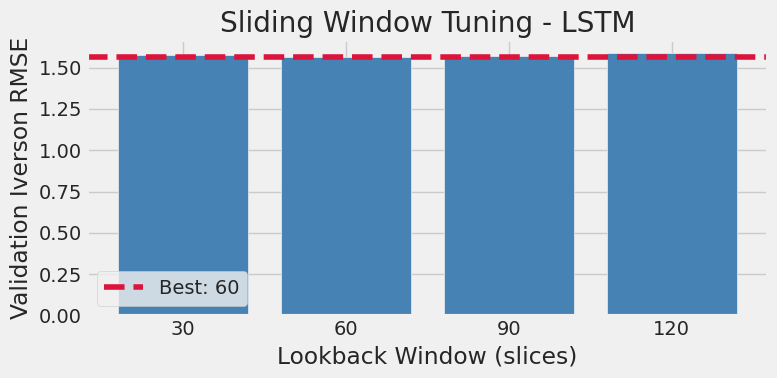

In [13]:
tuning['LSTM'] = tune_window('LSTM')
plot_window_tuning('LSTM', *tuning['LSTM'])

### GRU

GRU | window= 30 -> validation Iverson RMSE: 1.5111
GRU | window= 60 -> validation Iverson RMSE: 1.5217
GRU | window= 90 -> validation Iverson RMSE: 1.4299
GRU | window=120 -> validation Iverson RMSE: 1.5476
Selected window for GRU: 90


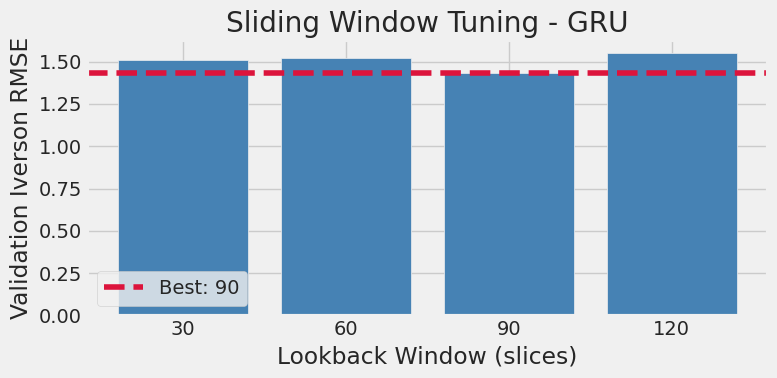

In [14]:
tuning['GRU'] = tune_window('GRU')
plot_window_tuning('GRU', *tuning['GRU'])

## 8. Training
Each model is trained with its selected window; the loss is the MSE on the standardized target.

In [15]:
def train_model(model_type):
    window_size = tuning[model_type][1]
    x_train, y_train, _ = create_sequences(0, train_end, window_size)
    x_val, y_val, _ = create_sequences(train_end, val_end, window_size)
    x_test, _, y_test_raw = create_sequences(val_end, len(dataset), window_size)

    model = build_model(model_type, window_size)
    history = model.fit(x_train, y_train, validation_data=(x_val, y_val),
                        batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=1)
    return model, history, (x_test, y_test_raw)


models, histories, test_sets = {}, {}, {}

### LSTM

In [16]:
models['LSTM'], histories['LSTM'], test_sets['LSTM'] = train_model('LSTM')

Epoch 1/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.4891 - val_loss: 0.2590
Epoch 2/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3256 - val_loss: 0.2257
Epoch 3/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.3045 - val_loss: 0.2256
Epoch 4/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2963 - val_loss: 0.2217
Epoch 5/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2779 - val_loss: 0.2285
Epoch 6/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2737 - val_loss: 0.2212
Epoch 7/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2709 - val_loss: 0.2302
Epoch 8/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.2517 - val_loss: 0.2282
Epoch 9/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2464 - val_loss: 0.2264
Epoch 10/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2435 - val_loss: 0.2287
Epoch 11/50
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.2523 - val_loss: 0.2340
Epoch 12/50
466/466 ━━━━━━━━━━━━━━━━━━━━

### GRU

In [17]:
models['GRU'], histories['GRU'], test_sets['GRU'] = train_model('GRU')

Epoch 1/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.4924 - val_loss: 0.2643
Epoch 2/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.3300 - val_loss: 0.2379
Epoch 3/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.3039 - val_loss: 0.2431
Epoch 4/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2972 - val_loss: 0.2508
Epoch 5/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2879 - val_loss: 0.2404
Epoch 6/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2807 - val_loss: 0.2317
Epoch 7/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2699 - val_loss: 0.2440
Epoch 8/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2641 - val_loss: 0.2323
Epoch 9/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2581 - val_loss: 0.2315
Epoch 10/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2533 - val_loss: 0.2365
Epoch 11/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2447 - val_loss: 0.2301
Epoch 12/50
465/465 ━━━━━━━━━━━━━━━━━━━━

## 9. Evaluation
Test-set predictions are mapped back to the original scale and scored with the Iverson metrics.

In [18]:
predictions, metrics_values = {}, {}
for model_type in MODEL_TYPES:
    x_test, y_test_raw = test_sets[model_type]
    predictions[model_type] = predict_original_scale(models[model_type], x_test)
    metrics_values[model_type] = {
        'I-MSE': iverson_mse(y_test_raw, predictions[model_type]),
        'I-RMSE': iverson_rmse(y_test_raw, predictions[model_type]),
        'I-MAE': iverson_mae(y_test_raw, predictions[model_type]),
    }

print(tabulate(
    [[name, f"{m['I-MSE']:.4f}", f"{m['I-RMSE']:.4f}", f"{m['I-MAE']:.4f}"] for name, m in metrics_values.items()],
    headers=['Model', 'I-MSE', 'I-RMSE', 'I-MAE'],
    tablefmt='pretty',
))

+-------+--------+--------+--------+
| Model | I-MSE  | I-RMSE | I-MAE  |
+-------+--------+--------+--------+
| LSTM  | 1.1999 | 1.0954 | 0.7488 |
|  GRU  | 1.1641 | 1.0789 | 0.7310 |
+-------+--------+--------+--------+


## 10. Visualizations
Prediction overlays and training curves for both models.

### Ground Truth vs Prediction

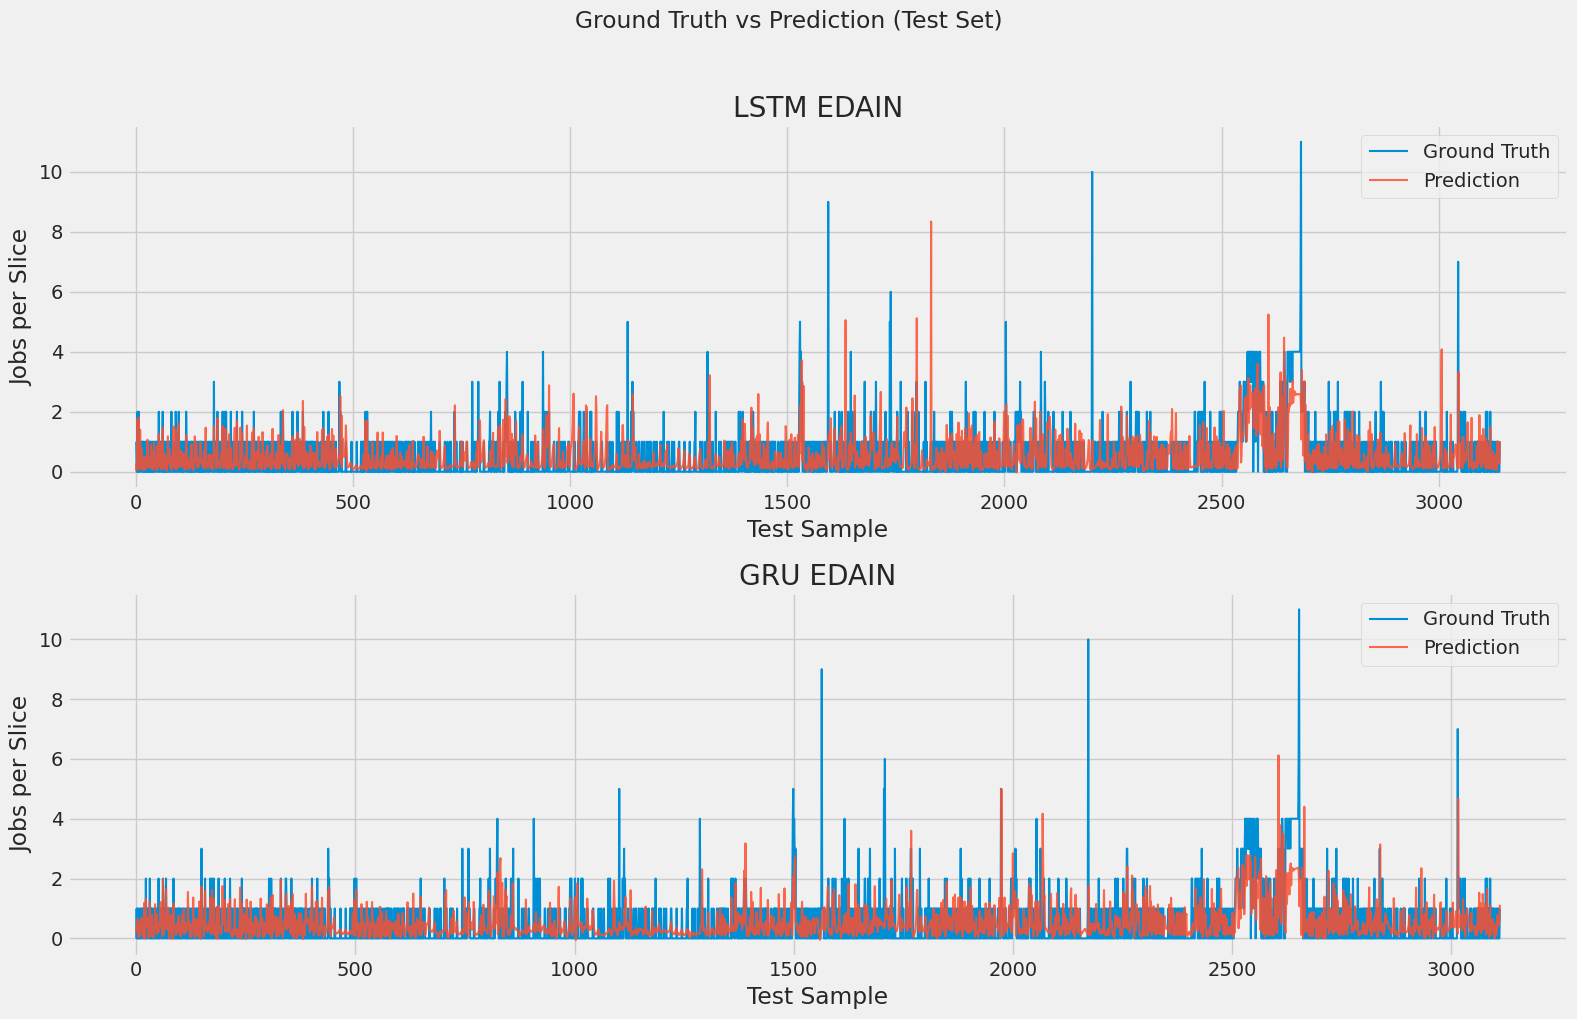

In [19]:
fig, axes = plt.subplots(len(MODEL_TYPES), 1, figsize=(16, 10))
for ax, model_type in zip(axes, MODEL_TYPES):
    ax.plot(test_sets[model_type][1], label='Ground Truth', linewidth=1.5)
    ax.plot(predictions[model_type], label='Prediction', linewidth=1.5, alpha=0.85)
    ax.set_title(f'{model_type} EDAIN')
    ax.set_xlabel('Test Sample')
    ax.set_ylabel('Jobs per Slice')
    ax.legend()

plt.suptitle('Ground Truth vs Prediction (Test Set)', y=1.02)
plt.tight_layout()
plt.show()

### Loss Curves

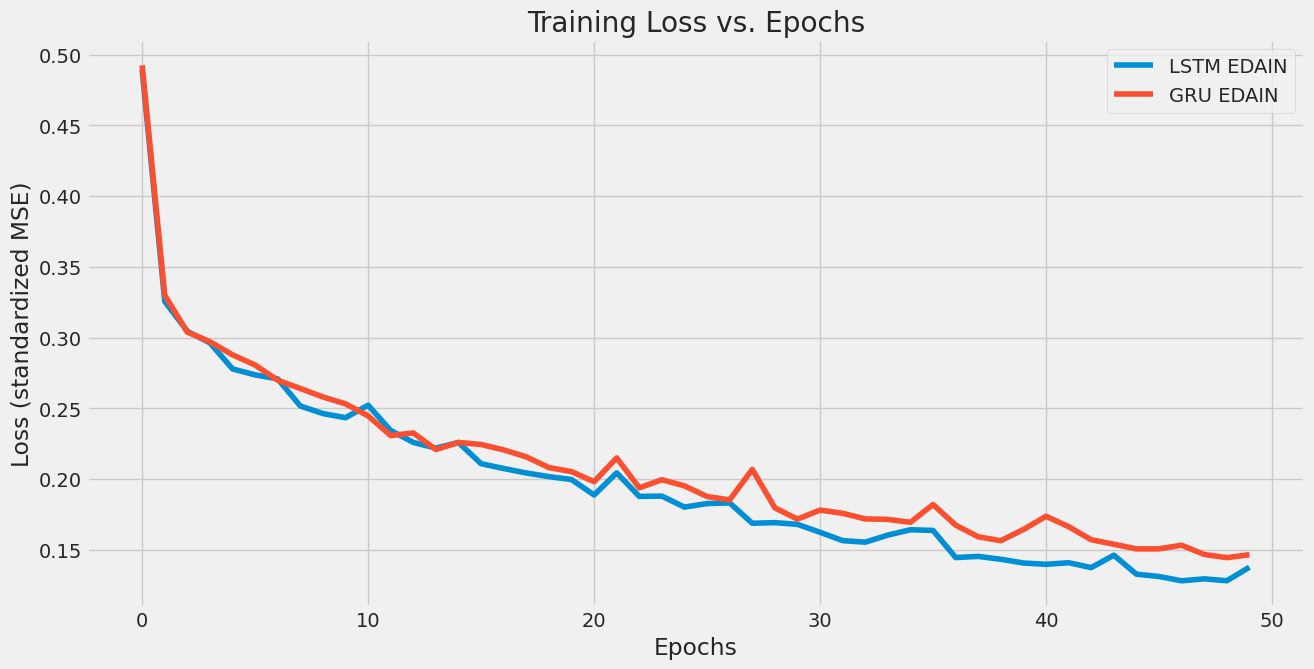

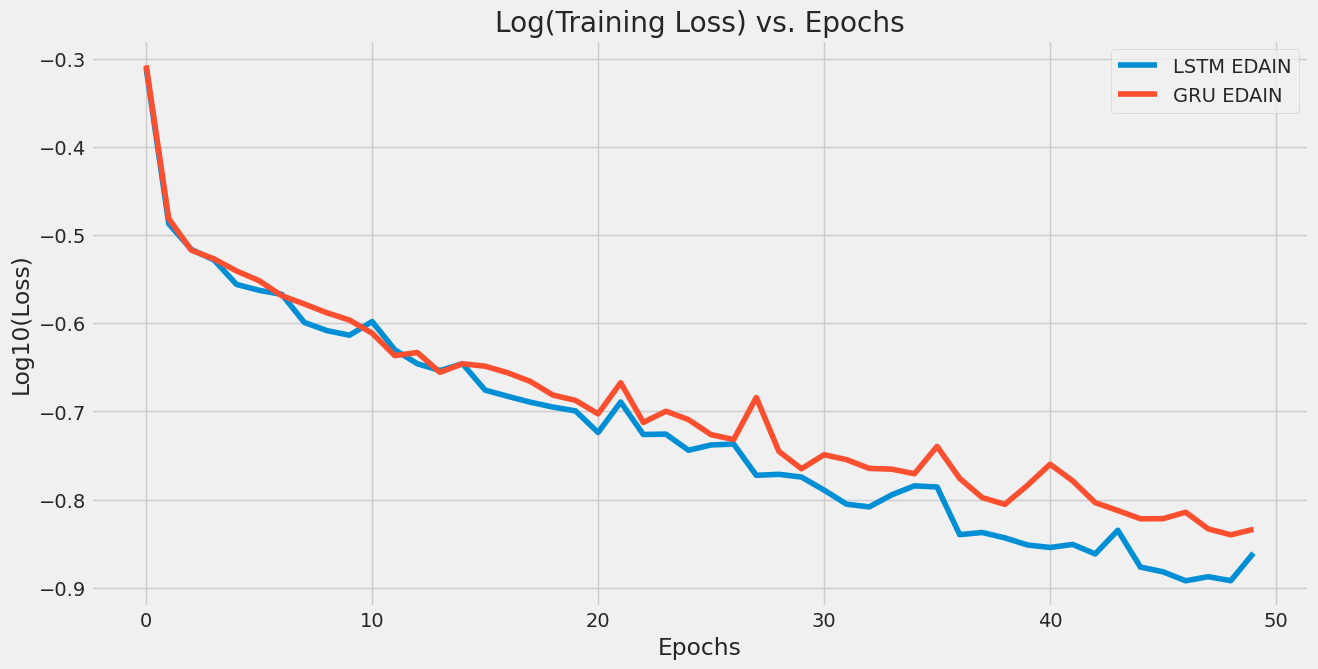

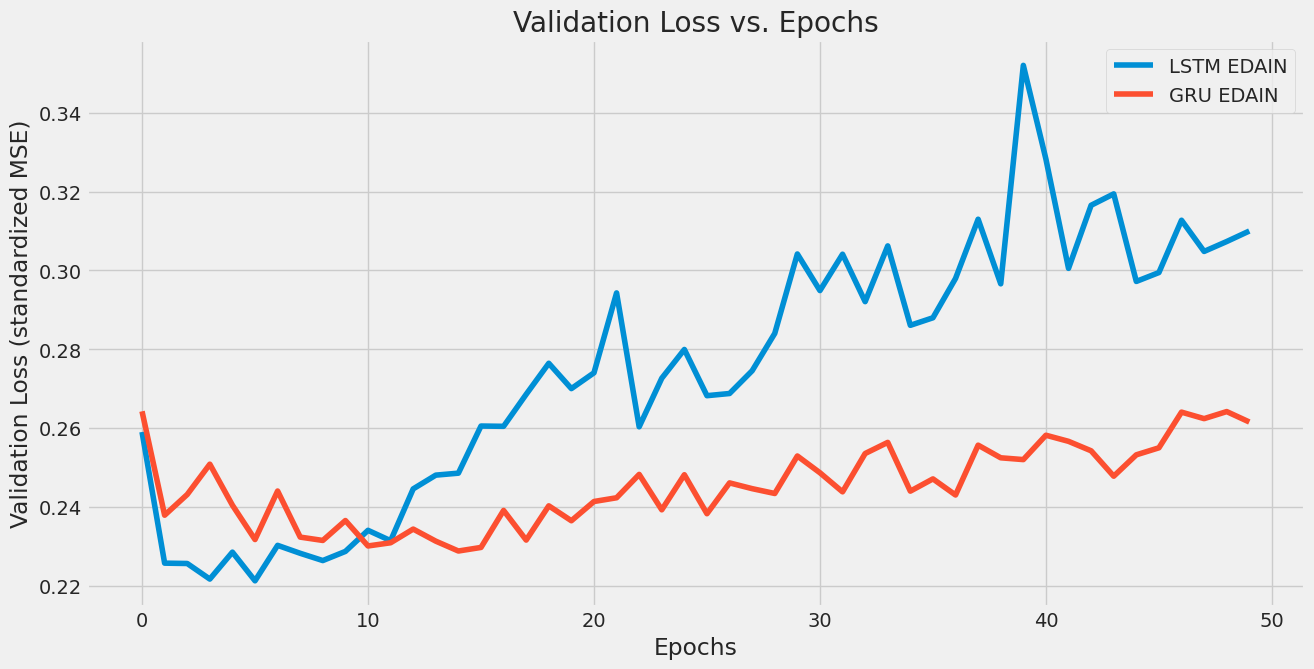

In [20]:
def plot_history(transform, key, title, ylabel):
    plt.figure(figsize=(14, 7))
    for model_type in MODEL_TYPES:
        plt.plot(transform(histories[model_type].history[key]), label=f'{model_type} EDAIN')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()


plot_history(np.asarray, 'loss', 'Training Loss vs. Epochs', 'Loss (standardized MSE)')
plot_history(lambda h: np.log10(h), 'loss', 'Log(Training Loss) vs. Epochs', 'Log10(Loss)')
plot_history(np.asarray, 'val_loss', 'Validation Loss vs. Epochs', 'Validation Loss (standardized MSE)')

### Final Loss

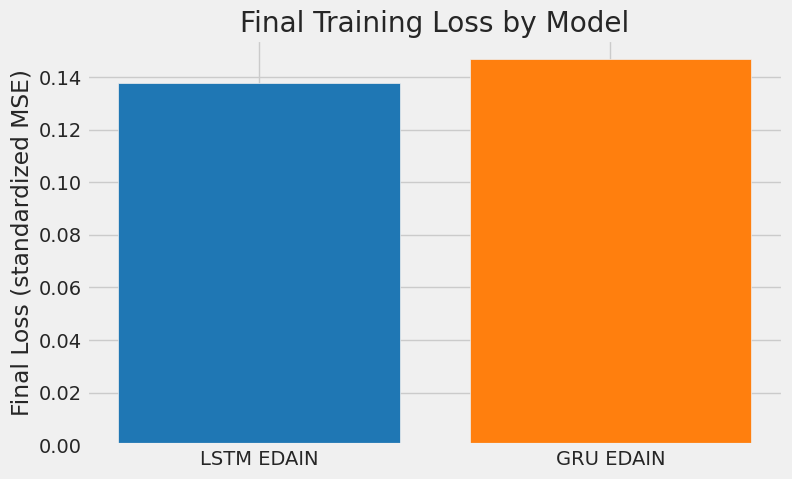

In [21]:
plt.figure(figsize=(8, 5))
plt.bar([f'{m} EDAIN' for m in MODEL_TYPES],
        [histories[m].history['loss'][-1] for m in MODEL_TYPES],
        color=['tab:blue', 'tab:orange'])
plt.title('Final Training Loss by Model')
plt.ylabel('Final Loss (standardized MSE)')
plt.show()

### Metrics Summary

In [22]:
summary = pd.DataFrame(metrics_values).T
summary.index.name = 'Model'
summary.style.format('{:.4f}')

,I-MSE,I-RMSE,I-MAE
Model,,,
LSTM,1.1999,1.0954,0.7488
GRU,1.1641,1.0789,0.7310
